<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/Deep-Learning-Projects/blob/main/Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = load_iris()
X, y = df.data, df.target
class_names = df.target_names

print("Features are: ", df.feature_names)
print("Prediction classes:", df.target_names)
print("Data set size:", X.shape[0])
print("\nExample sample: ", X[0], "->", y[0], ":", class_names[0])

Features are:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Prediction classes: ['setosa' 'versicolor' 'virginica']
Data set size: 150

Example sample:  [5.1 3.5 1.4 0.2] -> 0 : setosa


In [4]:
y.shape

(150,)

In [5]:
encoder = OneHotEncoder(sparse_output=False)
y_transformed = encoder.fit_transform(y.reshape(-1, 1))
y_transformed[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size = 0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
gd_model = Sequential()
gd_model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
gd_model.add(Dense(32, activation='relu'))
gd_model.add(Dense(3, activation='softmax'))
gd_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#GRADIENT DESCENT
gd_model.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics = ['accuracy'])
b_size = len(X_train_scaled)
GD_history = gd_model.fit(X_train_scaled, y_train, epochs = 50, batch_size = b_size, validation_data=(X_test_scaled, y_test), verbose=0)

In [10]:
sgd_model = Sequential()
sgd_model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
sgd_model.add(Dense(32, activation='relu'))
sgd_model.add(Dense(3, activation='softmax'))
sgd_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
sgd_model.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics = ['accuracy'])
SGD_history = sgd_model.fit(X_train_scaled, y_train, epochs = 50, validation_data=(X_test_scaled, y_test), verbose=0)

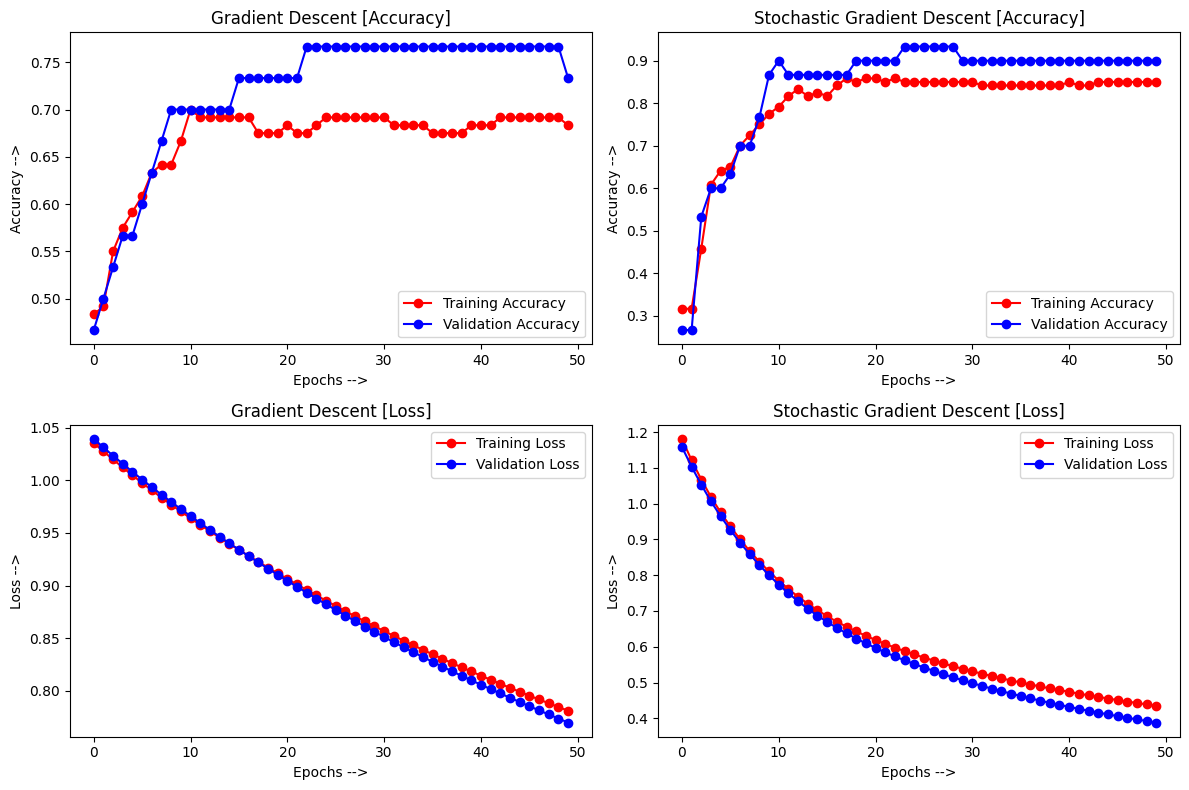

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(GD_history.history['accuracy'],color='r',marker='o', label='Training Accuracy')
ax[0, 0].plot(GD_history.history['val_accuracy'],color='b',marker='o', label='Validation Accuracy')
ax[0, 0].set_title('Gradient Descent [Accuracy]')
ax[0, 0].set_xlabel('Epochs -->')
ax[0, 0].set_ylabel('Accuracy -->')
ax[0, 0].legend()

ax[0, 1].plot(SGD_history.history['accuracy'],color='r',marker='o', label='Training Accuracy')
ax[0, 1].plot(SGD_history.history['val_accuracy'],color='b',marker='o', label='Validation Accuracy')
ax[0, 1].set_title('Stochastic Gradient Descent [Accuracy]')
ax[0, 1].set_xlabel('Epochs -->')
ax[0, 1].set_ylabel('Accuracy -->')
ax[0, 1].legend()

ax[1, 0].plot(GD_history.history['loss'],color='r',marker='o', label='Training Loss')
ax[1, 0].plot(GD_history.history['val_loss'],color='b',marker='o', label='Validation Loss')
ax[1, 0].set_title('Gradient Descent [Loss]')
ax[1, 0].set_xlabel('Epochs -->')
ax[1, 0].set_ylabel('Loss -->')
ax[1, 0].legend()

ax[1, 1].plot(SGD_history.history['loss'],color='r',marker='o', label='Training Loss')
ax[1, 1].plot(SGD_history.history['val_loss'],color='b',marker='o', label='Validation Loss')
ax[1, 1].set_title('Stochastic Gradient Descent [Loss]')
ax[1, 1].set_xlabel('Epochs -->')
ax[1, 1].set_ylabel('Loss -->')
ax[1, 1].legend()

plt.tight_layout()
plt.show()

## Conclusion

1. **Both Gradient Descent (GD) and Stochastic Gradient Descent (SGD) successfully reduced the loss** during training.

2. **SGD performed better than GD** on the Iris dataset:
   - GD validation accuracy: approximately **77\%**
   - SGD validation accuracy: approximately **90\%**

3. **SGD converged faster** than GD and reached a good accuracy in fewer epochs.

4. **SGD achieved a lower final loss** than GD, indicating better optimization of the model.

5. The training and validation curves are relatively stable, so there is **no strong indication of severe overfitting**.

6. **GD showed slower improvement and lower accuracy**, while SGD achieved better overall performance.

7. Therefore, **SGD was more effective than standard Gradient Descent** for the Iris classification task.

### Final Conclusion

> **From this experiment, it can be concluded that Stochastic Gradient Descent performs better than standard Gradient Descent for the Iris dataset. SGD provides faster convergence, higher accuracy, and lower loss, making it the better optimization method in this experiment.**
